# 03 — Preprocesamiento y reducción de dimensionalidad

Fase 3: codificación, escalado y reducción de dimensionalidad.

## Carga y revisión inicial

Partimos del archivo original para que los cambios queden separados del EDA. Primero identificamos la columna de consecutivo y revisamos duplicados usando las variables clínicas, sin contar ese identificador. Según el análisis de calidad no había duplicados, pero se vuelve a comprobar antes de transformar.

Los valores atípicos detectados en el EDA no se eliminan: pueden corresponder a resultados clínicos reales y no se identificaron como errores.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

rutas_candidatas = [
    Path("../data/raw/hcvdat0.csv"),
    Path("data/raw/hcvdat0.csv"),
]
ruta_hcv = next((ruta for ruta in rutas_candidatas if ruta.exists()), None)
if ruta_hcv is None:
    raise FileNotFoundError("No se encontró data/raw/hcvdat0.csv.")

df_original = pd.read_csv(ruta_hcv)
columna_id = df_original.columns[0]
columnas_datos = df_original.columns.drop(columna_id)

# El ID no describe al paciente; se excluye al buscar duplicados clínicos.
duplicados_clinicos = df_original.duplicated(
    subset=columnas_datos, keep="first"
)
print(f"Registros originales: {len(df_original)}")
print(f"Duplicados clínicos encontrados: {duplicados_clinicos.sum()}")

df_limpio = df_original.loc[~duplicados_clinicos].drop(columns=columna_id).copy()
print(f"Registros después de revisar duplicados: {len(df_limpio)}")
print(f"Columnas conservadas, sin identificador: {df_limpio.shape[1]}")
display(df_limpio.head())

Registros originales: 615
Duplicados clínicos encontrados: 0
Registros después de revisar duplicados: 615
Columnas conservadas, sin identificador: 13


,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,0=Blood Donor,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,0=Blood Donor,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,0=Blood Donor,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,0=Blood Donor,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,0=Blood Donor,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


### Tratamiento de faltantes

El EDA encontró 31 valores faltantes en 26 filas. Como la mayoría está en mediciones clínicas y `ALP` tiene faltantes concentrados en grupos de pacientes, no borramos esas filas. Para cada variable numérica usamos la mediana de su grupo `Category`; si algún grupo no tiene valores disponibles, usamos como respaldo la mediana general de esa variable.

También guardamos un indicador de faltante para `ALP`, porque en el EDA se observó que su ausencia se concentra en categorías clínicas. Esto permite conservar esa información después de imputar.

In [2]:
faltantes_antes = df_limpio.isna().sum()
if "ALP" in df_limpio.columns:
    df_limpio["ALP_faltante"] = df_limpio["ALP"].isna().astype("int8")

columnas_numericas = df_limpio.select_dtypes(include="number").columns.tolist()
columnas_imputadas = [
    columna for columna in columnas_numericas
    if df_limpio[columna].isna().any()
]

for columna in columnas_imputadas:
    mediana_general = df_limpio[columna].median()
    medianas_por_categoria = df_limpio.groupby(
        "Category", observed=False
    )[columna].transform("median")
    df_limpio[columna] = (
        df_limpio[columna]
        .fillna(medianas_por_categoria)
        .fillna(mediana_general)
    )

resumen_faltantes = pd.DataFrame({
    "Faltantes_antes": faltantes_antes,
    "Faltantes_despues": df_limpio.isna().sum(),
})
resumen_faltantes = resumen_faltantes.query(
    "Faltantes_antes > 0 or Faltantes_despues > 0"
)
display(resumen_faltantes)
print(f"Filas conservadas: {len(df_limpio)}")
print(f"Columnas imputadas: {columnas_imputadas}")
assert not df_limpio.isna().any().any(), "Quedaron valores faltantes sin tratar."

,Faltantes_antes,Faltantes_despues
ALB,1.0,0
ALP,18.0,0
ALT,1.0,0
CHOL,10.0,0
PROT,1.0,0


Filas conservadas: 615
Columnas imputadas: ['ALB', 'ALP', 'ALT', 'CHOL', 'PROT']


### Transformación y codificación

En el EDA se encontró sesgo positivo fuerte en `ALP`, `ALT`, `AST`, `BIL`, `CREA` y `GGT`. La prueba con `log1p` redujo ese sesgo, por eso aplicamos la transformación a esas seis variables después de imputar. No transformamos los otros marcadores, porque en ellos el logaritmo no mejoró la distribución.

`Category` y `Sex` son variables nominales, así que usamos One-Hot Encoding y no Label Encoding. Conservamos la categoría sospechosa como una clase independiente: con la información revisada no hay sustento para mezclarla con otra. La etiqueta de diagnóstico queda representada en columnas propias; esas columnas identifican la clase y no deben usarse como mediciones de entrada en un modelo.

In [3]:
df_modelo = df_limpio.copy()
categorias_diagnostico = df_modelo["Category"].copy()

variables_log = [
    "ALP", "ALT", "AST", "BIL", "CREA", "GGT",
]
variables_log = [
    columna for columna in variables_log if columna in df_modelo.columns
]

# log1p es válido porque el EDA no encontró mediciones clínicas no positivas.
for columna in variables_log:
    if (df_modelo[columna] < 0).any():
        raise ValueError(f"{columna} contiene valores negativos; no se aplica log1p.")
    df_modelo[f"log1p_{columna}"] = np.log1p(df_modelo[columna])
    df_modelo = df_modelo.drop(columns=columna)

columnas_categoricas = df_modelo.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()
df_procesado = pd.get_dummies(
    df_modelo,
    columns=columnas_categoricas,
    prefix=columnas_categoricas,
    dtype="int8",
)

print(f"Variables transformadas con log1p: {variables_log}")
print(f"Variables categóricas codificadas: {columnas_categoricas}")
print(f"Dimensiones del dataset procesado: {df_procesado.shape}")
print(f"¿Todas las columnas son numéricas?: {df_procesado.dtypes.apply(pd.api.types.is_numeric_dtype).all()}")
display(df_procesado.head())

Variables transformadas con log1p: ['ALP', 'ALT', 'AST', 'BIL', 'CREA', 'GGT']
Variables categóricas codificadas: ['Category', 'Sex']
Dimensiones del dataset procesado: (615, 19)
¿Todas las columnas son numéricas?: True


,Age,ALB,CHE,CHOL,PROT,ALP_faltante,log1p_ALP,log1p_ALT,log1p_AST,log1p_BIL,log1p_CREA,log1p_GGT,Category_0=Blood Donor,Category_0s=suspect Blood Donor,Category_1=Hepatitis,Category_2=Fibrosis,Category_3=Cirrhosis,Sex_f,Sex_m
0,32,38.5,6.93,3.23,69.0,0,3.979682,2.163323,3.139833,2.140066,4.672829,2.572612,1,0,0,0,0,0,1
1,32,38.5,11.17,4.80,76.5,0,4.266896,2.944439,3.246491,1.589235,4.317488,2.809403,1,0,0,0,0,0,1
2,32,46.9,8.84,5.20,79.3,0,4.326778,3.616309,3.981549,1.960095,4.465908,3.532226,1,0,0,0,0,0,1
3,32,43.2,7.33,4.74,75.7,0,3.970292,3.453157,3.161247,2.990720,4.394449,3.549617,1,0,0,0,0,0,1
4,32,39.2,9.15,4.32,68.7,0,4.318821,3.514526,3.250374,2.360854,4.343805,3.430756,1,0,0,0,0,0,1


In [4]:
# Verificaciones simples antes de guardar el resultado del preprocesamiento.
assert not df_procesado.isna().any().any(), "El dataset procesado tiene faltantes."
assert df_procesado.dtypes.apply(pd.api.types.is_numeric_dtype).all(), (
    "El dataset procesado tiene columnas no numéricas."
)

ruta_proyecto = ruta_hcv.resolve().parents[2]
ruta_salida = ruta_proyecto / "data" / "processed" / "hcv_processed.csv"
ruta_salida.parent.mkdir(parents=True, exist_ok=True)
df_procesado.to_csv(ruta_salida, index=False)

print(f"Archivo procesado guardado en: {ruta_salida}")
print(f"Valores faltantes finales: {int(df_procesado.isna().sum().sum())}")
print(f"Filas finales: {len(df_procesado)}")
print(
    "La serie `categorias_diagnostico` conserva la etiqueta original para "
    "interpretar o graficar los grupos en las siguientes etapas."
)

Archivo procesado guardado en: C:\Projects\Analisis_Datos_Evento_2\data\processed\hcv_processed.csv
Valores faltantes finales: 0
Filas finales: 615
La serie `categorias_diagnostico` conserva la etiqueta original para interpretar o graficar los grupos en las siguientes etapas.


## Escalado con StandardScaler

Para el PCA usamos solo las variables continuas del dataset procesado: la edad, los cuatro marcadores sin transformar (`ALB`, `CHE`, `CHOL`, `PROT`) y los seis marcadores con logaritmo. Dejamos por fuera:

- las columnas `Category_*`, porque son el diagnóstico. No entran al PCA, pero al final las usamos para colorear los puntos;
- `Sex_f`, `Sex_m` y `ALP_faltante`, porque son variables de 0 y 1. El PCA se basa en la varianza y en las relaciones lineales entre variables continuas, y una variable binaria no aporta mucho en ese sentido.

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

variables_pca = [
    "Age", "ALB", "CHE", "CHOL", "PROT",
    "log1p_ALP", "log1p_ALT", "log1p_AST", "log1p_BIL", "log1p_CREA", "log1p_GGT",
]
X = df_procesado[variables_pca]

# Varianza de cada variable antes de escalar
varianzas = X.var().sort_values(ascending=False).to_frame("Varianza")
varianzas["Porcentaje_del_total"] = varianzas["Varianza"] / varianzas["Varianza"].sum() * 100
display(varianzas.round(2))

,Varianza,Porcentaje_del_total
Age,101.11,58.91
ALB,33.48,19.51
PROT,29.15,16.98
CHE,4.86,2.83
CHOL,1.27,0.74
log1p_GGT,0.55,0.32
log1p_BIL,0.39,0.23
log1p_ALT,0.38,0.22
log1p_AST,0.24,0.14
log1p_ALP,0.11,0.06


**¿Por qué hay que escalar?** Como dice la guía de la semana 5, cuando las variables están en magnitudes distintas, las de números más grandes terminan pesando más aunque no sean más importantes. El PCA busca las direcciones de máxima varianza, así que sin escalar se quedaría casi solo con las variables de varianza grande.

La tabla lo muestra: `Age` sola tiene el 58.91 % de la varianza total, y junto con `ALB` y `PROT` pasan del 95 %. Las seis variables con logaritmo no llegan ni al 0.4 % cada una, porque el logaritmo las dejó en valores pequeños. Sin escalar, el PCA prácticamente resumiría la edad, que ni siquiera es un marcador de laboratorio.

`StandardScaler` le resta a cada variable su media y la divide por su desviación estándar:

z = (x - media) / desviación estándar

Así todas quedan con media 0 y desviación estándar 1, y ninguna domina por su escala. Usamos `StandardScaler` y no `MinMaxScaler` porque en el EDA decidimos conservar los valores atípicos, y `MinMaxScaler` depende del mínimo y el máximo, que son justamente los valores extremos.

In [6]:
escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)

# Comprobación: cada variable debe quedar con media 0 y desviación estándar 1
display(pd.DataFrame({
    "Media": X_escalado.mean(axis=0),
    "Desviacion_estandar": X_escalado.std(axis=0),
}, index=variables_pca).round(2))

,Media,Desviacion_estandar
Age,0.0,1.0
ALB,0.0,1.0
CHE,-0.0,1.0
CHOL,0.0,1.0
PROT,-0.0,1.0
log1p_ALP,-0.0,1.0
log1p_ALT,-0.0,1.0
log1p_AST,0.0,1.0
log1p_BIL,0.0,1.0
log1p_CREA,-0.0,1.0


Todas las variables quedaron con media 0 y desviación estándar 1. El escalado no cambia la forma de las distribuciones ni quita los atípicos, solo cambia las unidades: ahora cada valor se mide en desviaciones estándar respecto a la media de su variable. Con eso las 11 variables entran al PCA en igualdad de condiciones.

## Análisis de Componentes Principales (PCA)

Aplicamos el PCA con todas las componentes posibles (11, una por variable) para ver cuánta varianza explica cada una y decidir cuántas conservar.

In [7]:
pca = PCA()
componentes = pca.fit_transform(X_escalado)

nombres_pc = [f"PC{i}" for i in range(1, len(variables_pca) + 1)]
varianza_pca = pd.DataFrame({
    "Varianza_explicada": pca.explained_variance_ratio_ * 100,
    "Varianza_acumulada": pca.explained_variance_ratio_.cumsum() * 100,
}, index=nombres_pc)
display(varianza_pca.round(2))

for umbral in [80, 90]:
    componente = (varianza_pca["Varianza_acumulada"] >= umbral).idxmax()
    print(f"Para conservar al menos el {umbral} % de la varianza hay que llegar hasta {componente}")

,Varianza_explicada,Varianza_acumulada
PC1,21.23,21.23
PC2,18.46,39.69
PC3,13.68,53.37
PC4,10.00,63.37
PC5,8.25,71.62
PC6,6.60,78.22
PC7,5.74,83.95
PC8,4.88,88.83
PC9,4.58,93.41
PC10,3.72,97.13


Para conservar al menos el 80 % de la varianza hay que llegar hasta PC7
Para conservar al menos el 90 % de la varianza hay que llegar hasta PC9


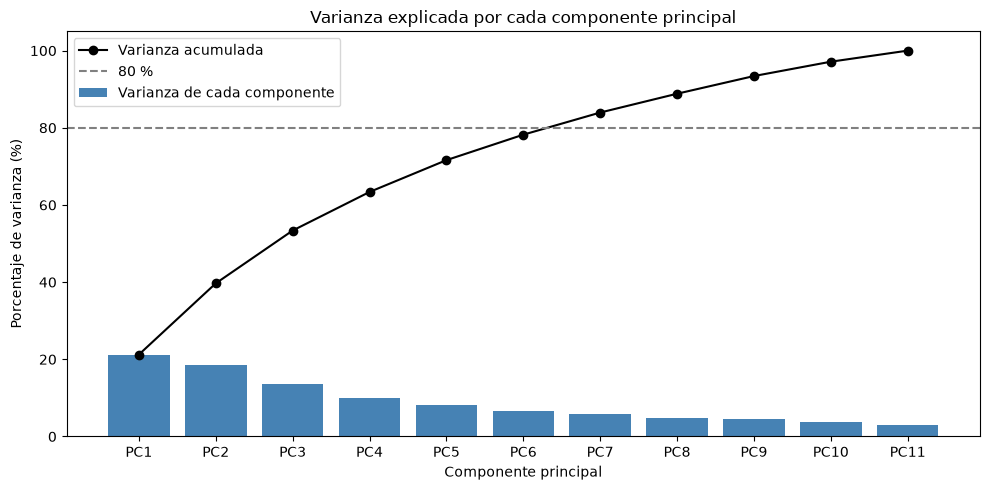

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(nombres_pc, varianza_pca["Varianza_explicada"], color="steelblue", label="Varianza de cada componente")
ax.plot(nombres_pc, varianza_pca["Varianza_acumulada"], color="black", marker="o", label="Varianza acumulada")
ax.axhline(80, color="gray", linestyle="--", label="80 %")
ax.set_title("Varianza explicada por cada componente principal")
ax.set_xlabel("Componente principal")
ax.set_ylabel("Porcentaje de varianza (%)")
ax.legend()
plt.tight_layout()
plt.show()

- PC1 explica el 21.23 % de la varianza y PC2 el 18.46 %. Juntas explican el 39.69 %.
- La varianza está bastante repartida: desde PC3 cada componente aporta entre el 13.68 % y el 2.87 %. Esto quiere decir que los marcadores no están tan correlacionados entre sí como para resumirlos en dos o tres componentes.
- Para conservar el 80 % de la información hay que llegar hasta PC7 (83.95 %), o sea, pasar de 11 variables a 7. Para el 90 % se necesitan 9 componentes.

Con 11 variables el dataset no tiene un problema grave de dimensionalidad, así que la reducción no es tan fuerte como en datasets con cientos de variables. Aun así, con 7 componentes se quitan 4 dimensiones y se pierde menos del 20 % de la varianza.

### ¿Qué representa cada componente?

Los pesos (loadings) indican cuánto aporta cada variable a cada componente. Un peso cercano a 1 o a -1 significa que la variable influye mucho en esa componente, y el signo indica la dirección.

In [9]:
cargas = pd.DataFrame(pca.components_[:2].T, index=variables_pca, columns=["PC1", "PC2"])
display(cargas.round(2).sort_values("PC1", ascending=False))

,PC1,PC2
CHE,0.49,0.05
ALB,0.48,0.05
PROT,0.40,0.23
CHOL,0.39,0.01
log1p_ALT,0.25,0.34
log1p_CREA,0.13,0.18
log1p_ALP,0.06,0.08
log1p_GGT,-0.07,0.56
Age,-0.15,0.07
log1p_AST,-0.21,0.56


- **PC1** tiene pesos positivos en `CHE` (0.49), `ALB` (0.48), `PROT` (0.40) y `CHOL` (0.39), y negativos en `log1p_BIL` (-0.24) y `log1p_AST` (-0.21). A un lado quedan los pacientes con proteínas, colinesterasa y colesterol altos, y al otro los que tienen bilirrubina y AST altas. Se podría leer PC1 como un eje de "hígado funcionando bien" contra "daño hepático".
- **PC2** tiene sus pesos más grandes en `log1p_AST` (0.56), `log1p_GGT` (0.56), `log1p_BIL` (0.39) y `log1p_ALT` (0.34). Resume qué tan elevadas están las enzimas del hígado.
- `Age`, `log1p_ALP` y `log1p_CREA` casi no pesan en ninguna de las dos, así que su información queda en las componentes siguientes.

## Visualización PC1 vs PC2

Proyectamos a todos los pacientes en las dos primeras componentes y los coloreamos según su diagnóstico. El PCA no conoce el diagnóstico, así que si los grupos se separan es porque los marcadores de laboratorio cambian con la enfermedad.

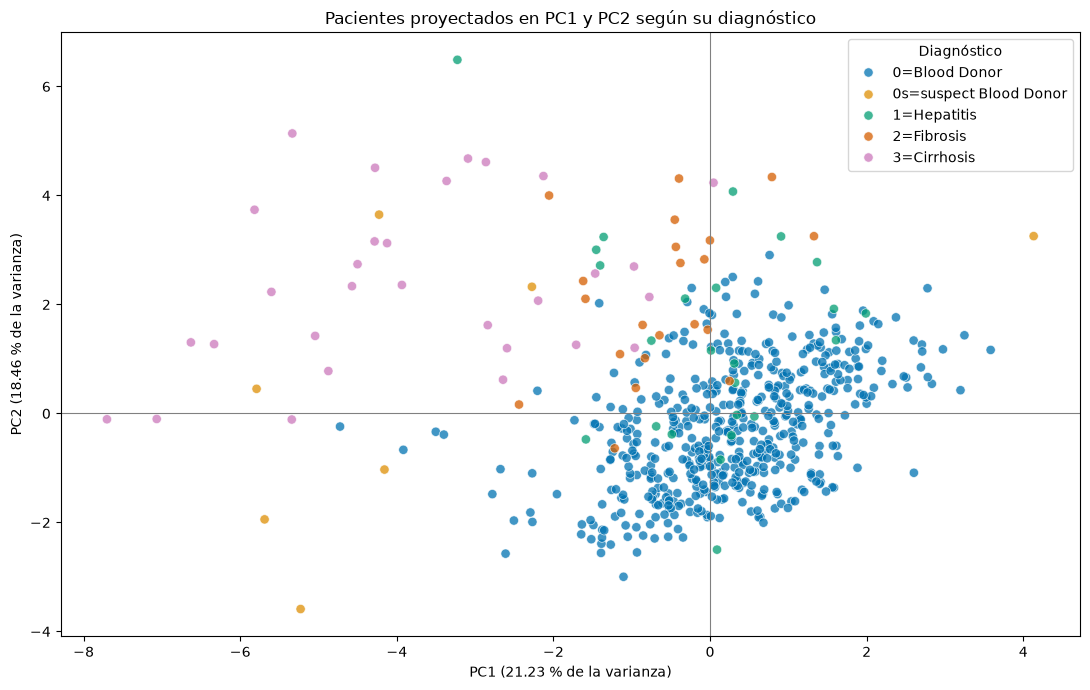

In [10]:
df_pca = pd.DataFrame(componentes[:, :2], columns=["PC1", "PC2"])
df_pca["Diagnóstico"] = categorias_diagnostico.to_numpy()

fig, ax = plt.subplots(figsize=(11, 7))
# Se ordena por diagnóstico para que los donantes se dibujen primero y no tapen a los demás grupos
sns.scatterplot(
    data=df_pca.sort_values("Diagnóstico"), x="PC1", y="PC2", hue="Diagnóstico",
    palette="colorblind", alpha=0.75, s=45, ax=ax,
)
ax.axhline(0, color="gray", linewidth=0.8)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_title("Pacientes proyectados en PC1 y PC2 según su diagnóstico")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f} % de la varianza)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f} % de la varianza)")
plt.tight_layout()
fig.savefig(Path("..") / "images" / "pca_pc1_pc2.png", dpi=150)
plt.show()

In [11]:
# Posición típica (mediana) de cada diagnóstico en las dos componentes
display(df_pca.groupby("Diagnóstico")[["PC1", "PC2"]].median().round(2))

,PC1,PC2
Diagnóstico,,
0=Blood Donor,0.30,-0.32
0s=suspect Blood Donor,-4.23,0.45
1=Hepatitis,0.11,1.34
2=Fibrosis,-0.45,2.10
3=Cirrhosis,-4.03,2.28


**Interpretación:**

- **Cuánto explican:** PC1 explica el 21.23 %, PC2 el 18.46 % y juntas el 39.69 % de la varianza. El gráfico es un buen resumen, pero deja por fuera el 60.31 % de la información.
- **Agrupamientos:** los donantes sanos forman una nube compacta cerca del centro (medianas de 0.30 en PC1 y -0.32 en PC2). Los pacientes con cirrosis y los donantes sospechosos se van hacia la izquierda, con medianas de PC1 de -4.03 y -4.23: tienen albúmina, colinesterasa y proteínas bajas. La hepatitis y la fibrosis se ubican sobre todo por encima de los donantes, con medianas de PC2 de 1.34 y 2.10, porque tienen las enzimas más altas.
- **Separación entre clases:** la cirrosis se separa bastante bien de los donantes con PC1. La hepatitis y la fibrosis se separan en parte con PC2, pero varios de esos pacientes quedan mezclados con los donantes. Con solo dos componentes no se alcanzan a separar todas las clases. También se ve que la mayoría de los donantes sospechosos quedan cerca de los pacientes con cirrosis y no de los donantes sanos.
- **Qué se pierde:** al quedarnos con dos componentes se pierde el 60.31 % de la varianza, incluida casi toda la información de `Age`, `log1p_ALP` y `log1p_CREA`. Para un modelo futuro conviene usar las 7 componentes que conservan más del 80 %, no solo PC1 y PC2.
- **Limitación:** el PCA es un método lineal y no usa el diagnóstico para construir las componentes. Como se ve en la guía de la semana 5, LDA sí busca la mayor separación entre clases, así que podría separar mejor la hepatitis y la fibrosis. Queda como posible línea de trabajo.

# Conclusiones del preprocesamiento y reducción

## Transformaciones realizadas y por qué

- **Duplicados:** se revisaron sin tener en cuenta el identificador y no se encontró ninguno, así que se conservaron los 615 registros. El identificador se quitó porque no es una medición del paciente.
- **Faltantes:** `ALB`, `ALP`, `ALT`, `CHOL` y `PROT` se llenaron con la mediana de su diagnóstico. Así no se perdieron las 26 filas incompletas, 19 de ellas de pacientes. Además, `ALP_faltante` guarda qué registros no tenían `ALP`, porque esa ausencia se concentraba en los pacientes.
- **Logaritmo:** se aplicó `log1p` a `ALP`, `ALT`, `AST`, `BIL`, `CREA` y `GGT` para reducir su sesgo positivo fuerte.
- **Codificación:** `Category` y `Sex` se codificaron con One-Hot Encoding porque son nominales; con Label Encoding se inventaría un orden que no existe. El resultado quedó en `data/processed/hcv_processed.csv`, con 615 filas y 19 columnas numéricas sin faltantes.
- **Escalado:** se estandarizaron 11 variables continuas con `StandardScaler` para que ninguna dominara el PCA por su escala.

## Qué produjo el PCA

PC1 explica el 21.23 % de la varianza y PC2 el 18.46 %, para un total de 39.69 %. Para conservar más del 80 % se necesitan 7 componentes (83.95 %), y para más del 90 %, 9 componentes (93.41 %).

PC1 resume sobre todo `CHE`, `ALB`, `PROT` y `CHOL`, y PC2 las enzimas `AST`, `GGT`, `BIL` y `ALT`. En la gráfica PC1 vs PC2, la cirrosis y los donantes sospechosos se separan de los donantes sanos, mientras que la hepatitis y la fibrosis solo se separan en parte.

## Utilidad futura y limitaciones

El dataset procesado queda listo para un modelo de clasificación: no tiene faltantes, todas sus columnas son numéricas y las categóricas están codificadas. Las columnas `Category_*` son la etiqueta, así que no se deben usar como variables de entrada.

Hay dos limitaciones que tener en cuenta:

1. El `ALB` = 82.2 del registro 217, que en el EDA se identificó como un error, no se corrigió en el preprocesamiento. Si se corrige, los resultados del PCA pueden cambiar un poco.
2. La imputación usó el diagnóstico de cada paciente para calcular la mediana. Eso sirve para describir los datos, pero si más adelante se quiere predecir el diagnóstico, habría que llenar los faltantes sin usarlo.